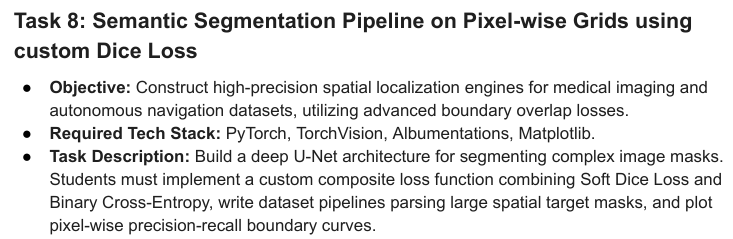

In [1]:
!pip install torch torchvision albumentations matplotlib scikit-learn

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader

In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cpu


In [4]:
class SimpleSegmentationDataset(Dataset):

    def __init__(
        self,
        num_samples=100,
        image_size=128
    ):

        self.num_samples = num_samples
        self.image_size = image_size

    def __len__(self):

        return self.num_samples

    def __getitem__(self, index):

        image = np.zeros(
            (self.image_size, self.image_size),
            dtype=np.float32
        )

        mask = np.zeros(
            (self.image_size, self.image_size),
            dtype=np.float32
        )

        # Random circle
        center_x = np.random.randint(
            30,
            self.image_size - 30
        )

        center_y = np.random.randint(
            30,
            self.image_size - 30
        )

        radius = np.random.randint(
            10,
            25
        )

        y, x = np.ogrid[
            :self.image_size,
            :self.image_size
        ]

        circle = (
            (x - center_x) ** 2
            +
            (y - center_y) ** 2
            <= radius ** 2
        )

        mask[circle] = 1

        # Add noise to image
        image = mask * 0.8

        noise = np.random.normal(
            0,
            0.1,
            image.shape
        )

        image = image + noise

        image = np.clip(
            image,
            0,
            1
        )

        image = torch.tensor(
            image,
            dtype=torch.float32
        ).unsqueeze(0)

        mask = torch.tensor(
            mask,
            dtype=torch.float32
        ).unsqueeze(0)

        return image, mask

In [5]:
train_dataset = SimpleSegmentationDataset(
    num_samples=100,
    image_size=128
)

val_dataset = SimpleSegmentationDataset(
    num_samples=20,
    image_size=128
)

In [6]:
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False
)

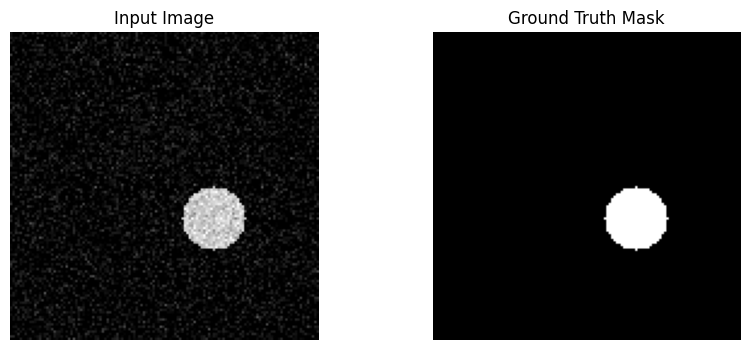

In [7]:
image, mask = train_dataset[0]

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)

plt.imshow(
    image.squeeze(),
    cmap="gray"
)

plt.title("Input Image")

plt.axis("off")


plt.subplot(1, 2, 2)

plt.imshow(
    mask.squeeze(),
    cmap="gray"
)

plt.title("Ground Truth Mask")

plt.axis("off")

plt.show()

In [8]:
class DoubleConv(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()

        self.block = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(inplace=True)
        )

    def forward(self, x):

        return self.block(x)

In [9]:
class UNet(nn.Module):

    def __init__(self):

        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(1, 32)

        self.enc2 = DoubleConv(32, 64)

        self.enc3 = DoubleConv(64, 128)

        # Bottleneck
        self.bottleneck = DoubleConv(
            128,
            256
        )

        # Pooling
        self.pool = nn.MaxPool2d(
            2
        )

        # Decoder
        self.up3 = nn.ConvTranspose2d(
            256,
            128,
            kernel_size=2,
            stride=2
        )

        self.dec3 = DoubleConv(
            256,
            128
        )

        self.up2 = nn.ConvTranspose2d(
            128,
            64,
            kernel_size=2,
            stride=2
        )

        self.dec2 = DoubleConv(
            128,
            64
        )

        self.up1 = nn.ConvTranspose2d(
            64,
            32,
            kernel_size=2,
            stride=2
        )

        self.dec1 = DoubleConv(
            64,
            32
        )

        # Final segmentation layer
        self.final = nn.Conv2d(
            32,
            1,
            kernel_size=1
        )

    def forward(self, x):

        # -------------------------
        # Encoder
        # -------------------------

        e1 = self.enc1(x)

        p1 = self.pool(e1)

        e2 = self.enc2(p1)

        p2 = self.pool(e2)

        e3 = self.enc3(p2)

        p3 = self.pool(e3)

        # -------------------------
        # Bottleneck
        # -------------------------

        b = self.bottleneck(p3)

        # -------------------------
        # Decoder 3
        # -------------------------

        d3 = self.up3(b)

        d3 = torch.cat(
            [d3, e3],
            dim=1
        )

        d3 = self.dec3(d3)

        # -------------------------
        # Decoder 2
        # -------------------------

        d2 = self.up2(d3)

        d2 = torch.cat(
            [d2, e2],
            dim=1
        )

        d2 = self.dec2(d2)

        # -------------------------
        # Decoder 1
        # -------------------------

        d1 = self.up1(d2)

        d1 = torch.cat(
            [d1, e1],
            dim=1
        )

        d1 = self.dec1(d1)

        # -------------------------
        # Output
        # -------------------------

        output = self.final(d1)

        return output

In [10]:
model = UNet().to(device)

print(model)

UNet(
  (enc1): DoubleConv(
    (block): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (enc2): DoubleConv(
    (block): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (enc3): DoubleConv(
    (block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (bottleneck): DoubleConv(
    (block): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d

In [11]:
test_input = torch.randn(
    2,
    1,
    128,
    128
).to(device)

test_output = model(
    test_input
)

print(
    "Input:",
    test_input.shape
)

print(
    "Output:",
    test_output.shape
)

Input: torch.Size([2, 1, 128, 128])
Output: torch.Size([2, 1, 128, 128])


In [12]:
def dice_loss(
    predictions,
    targets,
    smooth=1e-6
):

    predictions = torch.sigmoid(
        predictions
    )

    predictions = predictions.view(
        -1
    )

    targets = targets.view(
        -1
    )

    intersection = (
        predictions * targets
    ).sum()

    dice = (
        2 * intersection
        + smooth
    ) / (
        predictions.sum()
        +
        targets.sum()
        +
        smooth
    )

    return 1 - dice

In [13]:
bce_loss = nn.BCEWithLogitsLoss()

In [14]:
def combined_loss(
    predictions,
    targets
):

    dice = dice_loss(
        predictions,
        targets
    )

    bce = bce_loss(
        predictions,
        targets
    )

    return dice + bce

In [15]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [16]:
epochs = 3

train_losses = []

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for images, masks in train_loader:

        images = images.to(device)

        masks = masks.to(device)

        # Forward
        predictions = model(images)

        # Loss
        loss = combined_loss(
            predictions,
            masks
        )

        # Backpropagation
        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = (
        running_loss
        /
        len(train_loader)
    )

    train_losses.append(
        epoch_loss
    )

    print(
        f"Epoch {epoch+1}/{epochs} "
        f"Loss: {epoch_loss:.4f}"
    )

Epoch 1/3 Loss: 1.3886
Epoch 2/3 Loss: 0.7280
Epoch 3/3 Loss: 0.3483


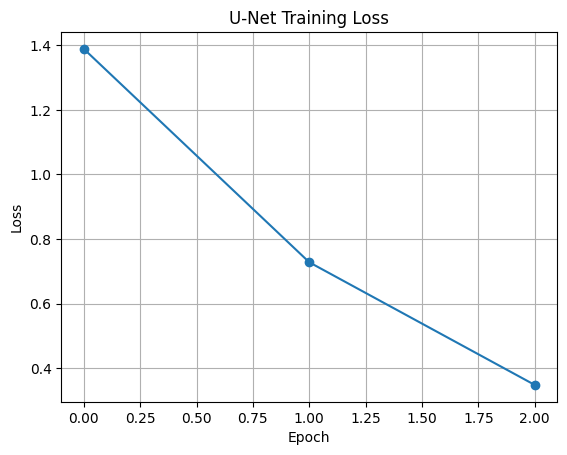

In [17]:
plt.plot(
    train_losses,
    marker="o"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "U-Net Training Loss"
)

plt.grid()

plt.show()

In [18]:
model.eval()

images, masks = next(
    iter(val_loader)
)

images = images.to(device)

masks = masks.to(device)

with torch.no_grad():

    predictions = model(
        images
    )

probabilities = torch.sigmoid(
    predictions
)

In [19]:
predicted_masks = (
    probabilities > 0.5
).float()

In [20]:
def dice_score(
    predictions,
    targets,
    smooth=1e-6
):

    predictions = predictions.view(
        -1
    )

    targets = targets.view(
        -1
    )

    intersection = (
        predictions * targets
    ).sum()

    return (
        2 * intersection
        + smooth
    ) / (
        predictions.sum()
        +
        targets.sum()
        +
        smooth
    )

In [21]:
score = dice_score(
    predicted_masks,
    masks
)

print(
    "Dice Score:",
    score.item()
)

Dice Score: 0.984204888343811


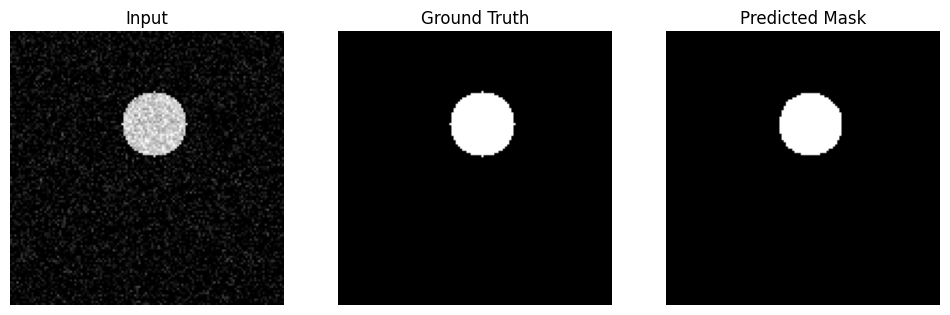

In [22]:
image = images[0].cpu().squeeze()

true_mask = masks[0].cpu().squeeze()

pred_mask = (
    predicted_masks[0]
    .cpu()
    .squeeze()
)

plt.figure(figsize=(12, 4))

# Input
plt.subplot(1, 3, 1)

plt.imshow(
    image,
    cmap="gray"
)

plt.title("Input")

plt.axis("off")


# Ground truth
plt.subplot(1, 3, 2)

plt.imshow(
    true_mask,
    cmap="gray"
)

plt.title("Ground Truth")

plt.axis("off")


# Prediction
plt.subplot(1, 3, 3)

plt.imshow(
    pred_mask,
    cmap="gray"
)

plt.title("Predicted Mask")

plt.axis("off")

plt.show()

In [23]:
from sklearn.metrics import precision_score, recall_score

In [24]:
thresholds = np.linspace(
    0.1,
    0.9,
    9
)

precisions = []

recalls = []

true_pixels = (
    masks.cpu()
    .numpy()
    .flatten()
)

prob_pixels = (
    probabilities.cpu()
    .numpy()
    .flatten()
)

for threshold in thresholds:

    predicted_pixels = (
        prob_pixels >= threshold
    ).astype(int)

    precision = precision_score(
        true_pixels,
        predicted_pixels,
        zero_division=0
    )

    recall = recall_score(
        true_pixels,
        predicted_pixels,
        zero_division=0
    )

    precisions.append(
        precision
    )

    recalls.append(
        recall
    )

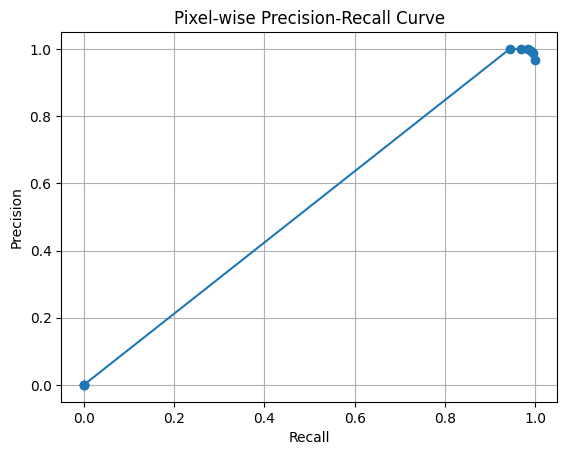

In [25]:
splt.plot(
    recalls,
    precisions,
    marker="o"
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title(
    "Pixel-wise Precision-Recall Curve"
)

plt.grid()

plt.show()